<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana5/LASSO_Ridge_ElasticNet_clase_mejorado_EJECUTADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller mejorado: Ridge, LASSO y Elastic Net

## Regresión lineal regularizada paso a paso

Este notebook está diseñado para una clase completa. La idea no es solo ejecutar modelos, sino entender:

1. por qué aparece la regularización;
2. qué cambia entre regresión lineal, Ridge, LASSO y Elastic Net;
3. cómo se selecciona el parámetro de penalización mediante validación cruzada;
4. qué ocurre con los coeficientes cuando aumenta la penalización;
5. cómo comparar los modelos en términos de predicción, estabilidad e interpretación.

## Objetivo de aprendizaje

Al final de la actividad el estudiante debe poder explicar que:

- Ridge reduce los coeficientes, pero normalmente no los vuelve exactamente cero.
- LASSO puede hacer selección automática de variables porque algunos coeficientes quedan exactamente en cero.
- Elastic Net combina la estabilidad de Ridge con la selección de variables de LASSO.
- El mejor valor de la penalización no se escoge mirando el test, sino mediante validación cruzada sobre el conjunto de entrenamiento.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = Path("figs_lasso_ridge_elasticnet")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def guardar_figura(nombre):
    ruta = FIG_DIR / nombre
    plt.tight_layout()
    plt.savefig(ruta, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Figura guardada en: {ruta}")

# 1. Carga y organización de los datos

Usaremos la base de datos `diabetes` de `sklearn`. Es una base pequeña pero muy útil para enseñar regresión porque tiene:

- una variable respuesta continua;
- varias variables predictoras numéricas;
- correlaciones importantes entre algunos predictores;
- un tamaño razonable para ver validación cruzada rápidamente.

In [ ]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data.copy()
y = diabetes.target.copy()

print(diabetes.DESCR.split("\n")[0:10])
print("\nDimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Variables predictoras:", list(X.columns))

X.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=0
)

print(f"Observaciones de entrenamiento: {X_train.shape[0]}")
print(f"Observaciones de prueba:       {X_test.shape[0]}")
print(f"Número de variables:           {X_train.shape[1]}")

# 2. Exploración inicial de los datos

Antes de ajustar modelos, conviene observar la distribución de la respuesta y la relación entre algunas variables predictoras y el objetivo.

Aunque la base `diabetes` ya viene estandarizada de cierta forma, en esta clase aplicaremos `StandardScaler` dentro de cada `Pipeline`. Esto es una práctica importante porque Ridge, LASSO y Elastic Net dependen de la escala de las variables.

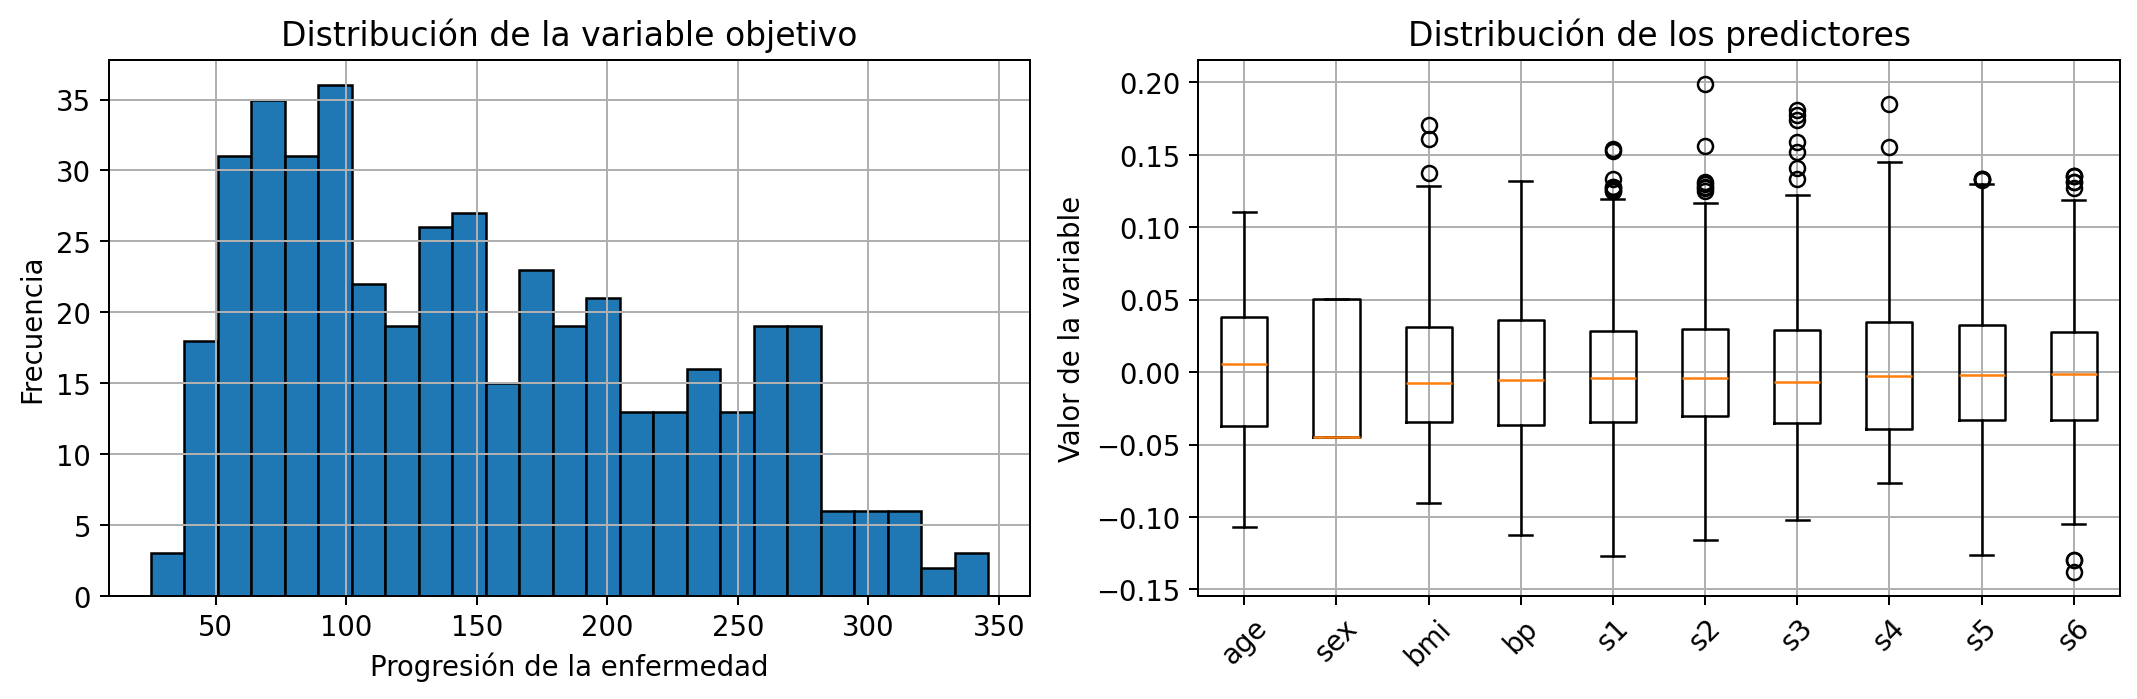

Figura guardada en: figs_lasso_ridge_elasticnet/01_distribucion_target_y_predictores.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=25, edgecolor="black")
axes[0].set_title("Distribución de la variable objetivo")
axes[0].set_xlabel("Progresión de la enfermedad")
axes[0].set_ylabel("Frecuencia")

axes[1].boxplot([X[col] for col in X.columns], tick_labels=X.columns, vert=True)
axes[1].set_title("Distribución de los predictores")
axes[1].set_ylabel("Valor de la variable")
axes[1].tick_params(axis="x", rotation=45)

guardar_figura("01_distribucion_target_y_predictores.png")

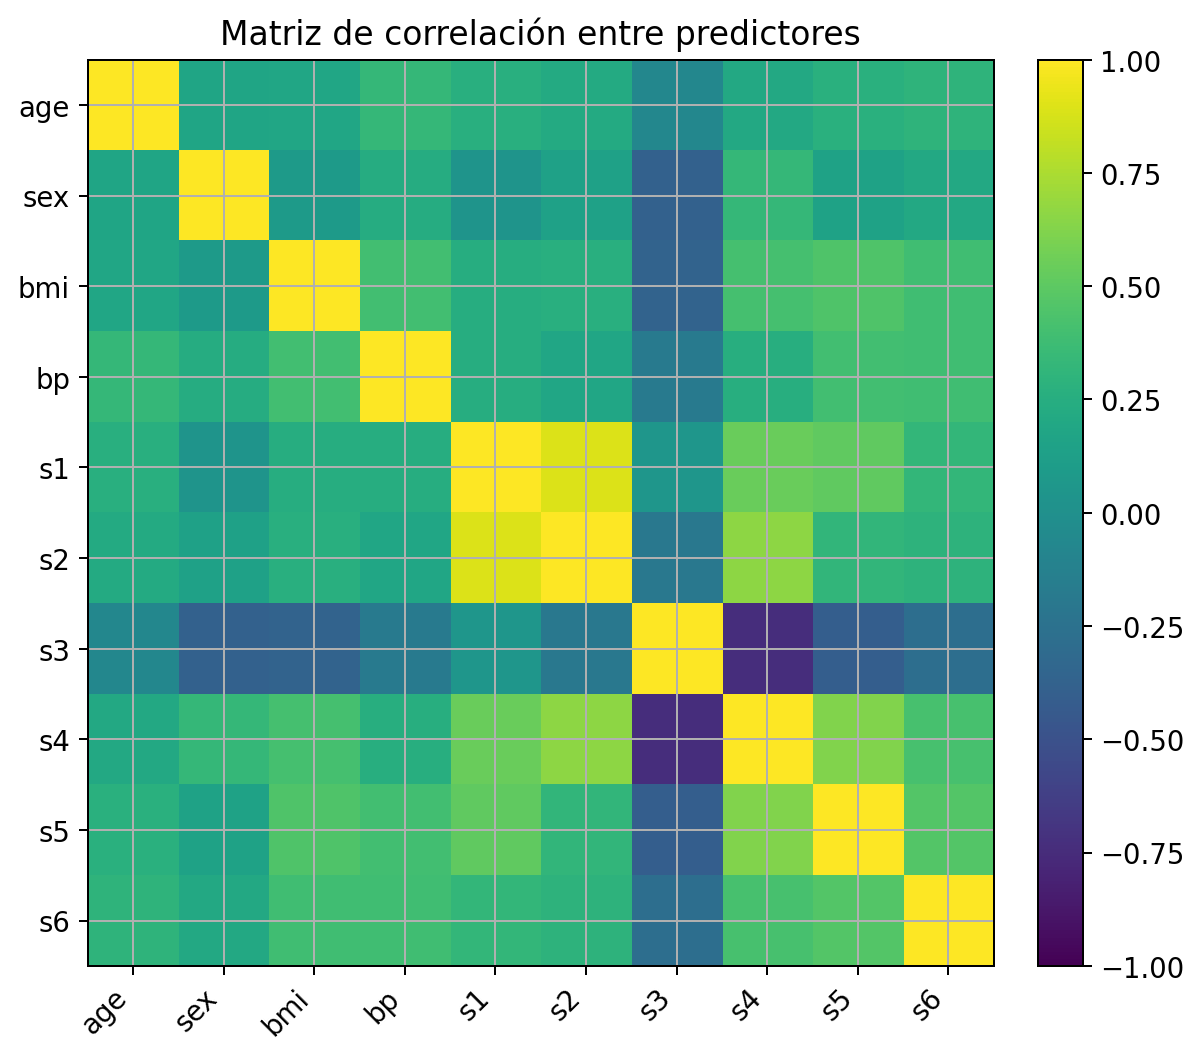

Figura guardada en: figs_lasso_ridge_elasticnet/02_matriz_correlacion.png


In [ ]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(X.columns)))
ax.set_yticks(range(len(X.columns)))
ax.set_xticklabels(X.columns, rotation=45, ha="right")
ax.set_yticklabels(X.columns)
ax.set_title("Matriz de correlación entre predictores")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

guardar_figura("02_matriz_correlacion.png")

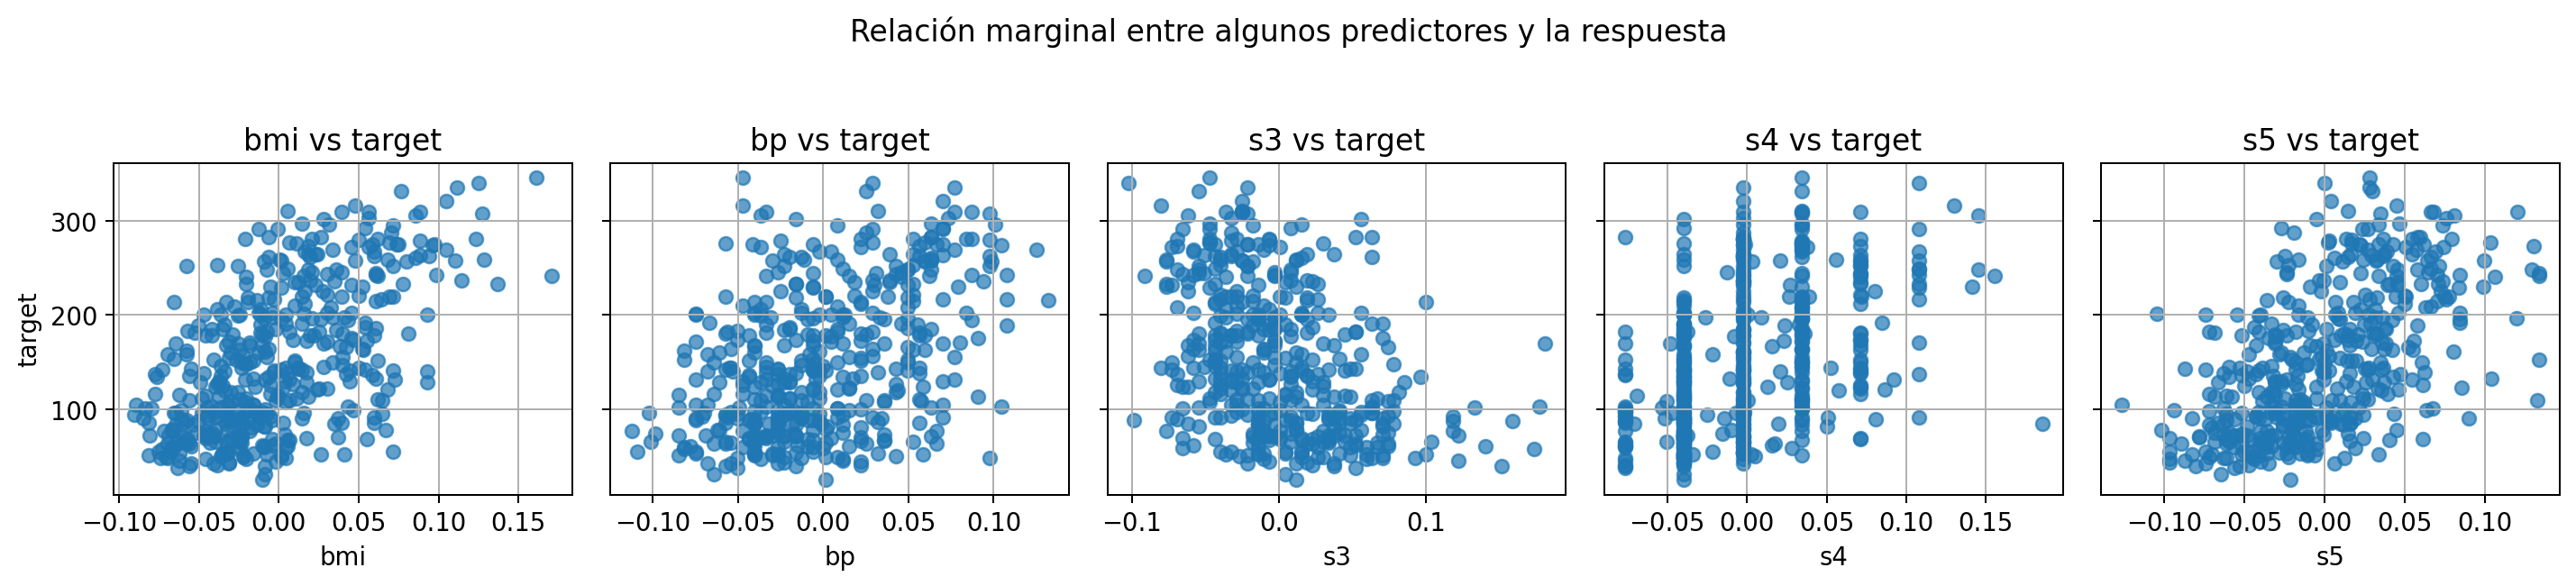

Figura guardada en: figs_lasso_ridge_elasticnet/03_dispersion_variables_target.png


In [ ]:
variables_interes = ["bmi", "bp", "s3", "s4", "s5"]
fig, axes = plt.subplots(1, len(variables_interes), figsize=(16, 3.4), sharey=True)

for ax, col in zip(axes, variables_interes):
    ax.scatter(X[col], y, alpha=0.7)
    ax.set_xlabel(col)
    ax.set_title(f"{col} vs target")

axes[0].set_ylabel("target")
fig.suptitle("Relación marginal entre algunos predictores y la respuesta", y=1.05)

guardar_figura("03_dispersion_variables_target.png")

# 3. Modelo de referencia: regresión lineal sin regularización

La regresión lineal ordinaria ajusta el modelo

\[
\hat y_i = \beta_0 + \beta_1x_{i1}+\cdots+\beta_px_{ip}.
\]

El problema es que, cuando hay predictores correlacionados o muchas variables respecto al número de datos, los coeficientes pueden volverse inestables. La regularización controla ese problema agregando una penalización al tamaño de los coeficientes.

In [ ]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    return {
        "modelo": nombre,
        "MSE": mean_squared_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }

modelo_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
modelo_lineal.fit(X_train, y_train)

metricas_lineal = evaluar_modelo("Regresión lineal", modelo_lineal, X_test, y_test)
pd.DataFrame([metricas_lineal])

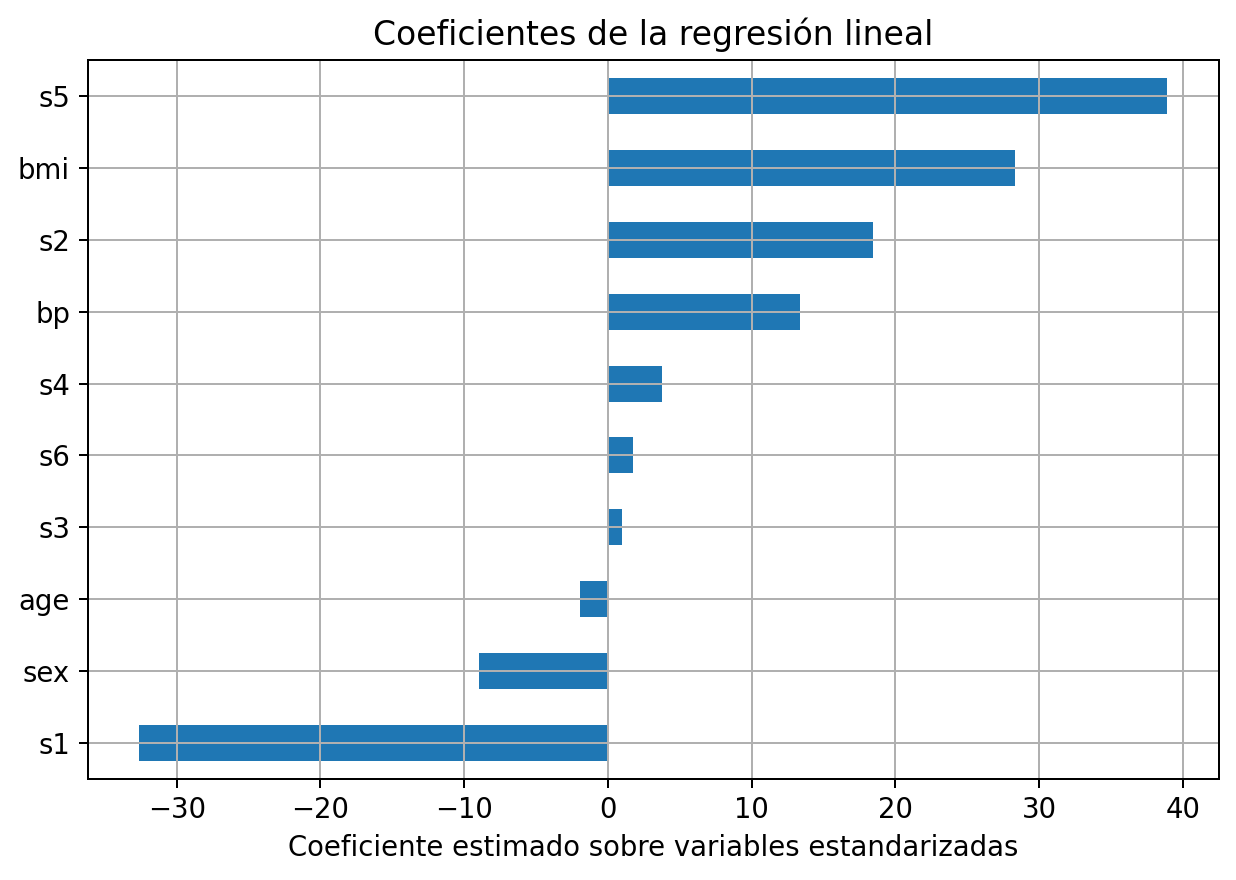

Figura guardada en: figs_lasso_ridge_elasticnet/04_coeficientes_lineal.png


In [ ]:
coef_lineal = pd.Series(
    modelo_lineal.named_steps["model"].coef_,
    index=X.columns,
    name="Regresión lineal"
)

coef_lineal.sort_values().plot(kind="barh", figsize=(7, 5))
plt.title("Coeficientes de la regresión lineal")
plt.xlabel("Coeficiente estimado sobre variables estandarizadas")
guardar_figura("04_coeficientes_lineal.png")

# 4. La idea de regularización

En lugar de minimizar solamente el error cuadrático,

\[
\sum_{i=1}^n (y_i-\hat y_i)^2,
\]

los modelos regularizados minimizan

\[
\text{error de ajuste} + \text{penalización}.
\]

La penalización evita que los coeficientes crezcan demasiado.

## Ridge

\[
\min_{\beta} \sum_{i=1}^{n}(y_i - x_i^T\beta)^2 + \alpha \sum_{j=1}^{p}\beta_j^2.
\]

## LASSO

\[
\min_{\beta} \sum_{i=1}^{n}(y_i - x_i^T\beta)^2 + \alpha \sum_{j=1}^{p}|\beta_j|.
\]

## Elastic Net

En `sklearn`, Elastic Net usa la forma

\[
\frac{1}{2n}\|y-X\beta\|_2^2
+\alpha\,\rho\|\beta\|_1
+\frac{1}{2}\alpha(1-\rho)\|\beta\|_2^2,
\]

donde \(\rho=\texttt{l1\_ratio}\). Si \(\rho=1\), se parece a LASSO; si \(\rho\) es pequeño, se parece más a Ridge.

# 5. Intuición geométrica: Ridge vs LASSO

La diferencia entre Ridge y LASSO se puede entender mirando la región permitida para los coeficientes.

- Ridge usa una bola circular o elíptica: tiende a reducir todos los coeficientes suavemente.
- LASSO usa una región con esquinas: esas esquinas facilitan soluciones con coeficientes exactamente iguales a cero.

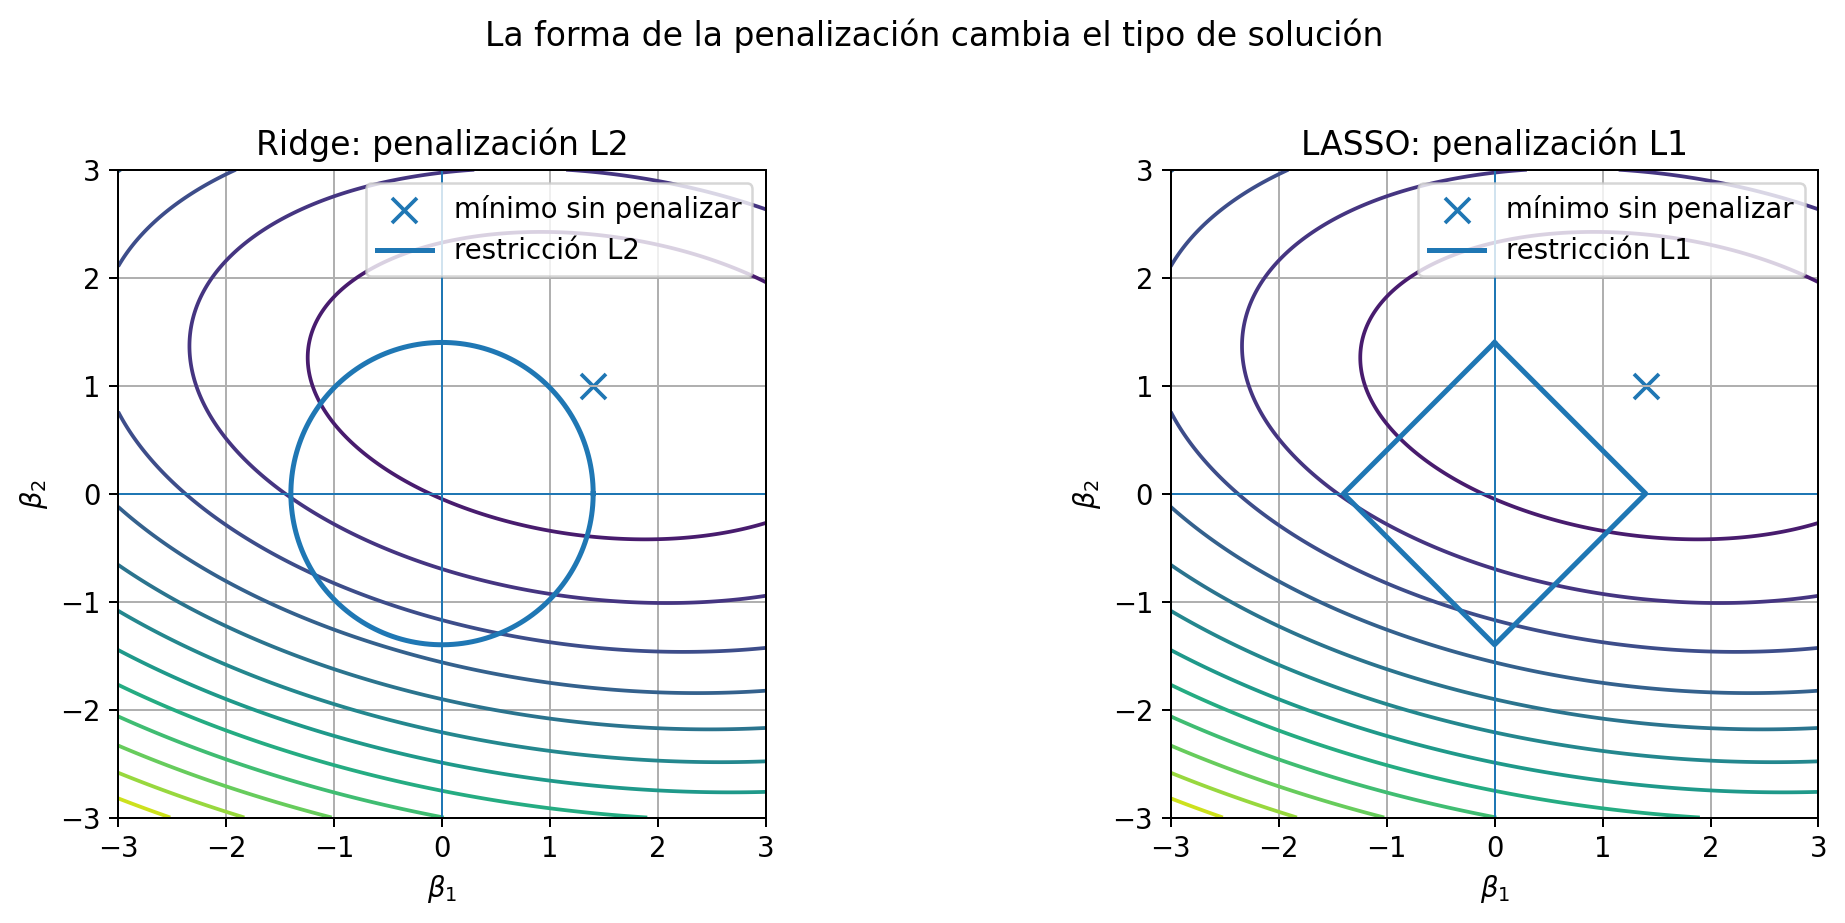

Figura guardada en: figs_lasso_ridge_elasticnet/05_geometria_l1_l2.png


In [ ]:
# Ilustración geométrica en dos dimensiones
b1 = np.linspace(-3, 3, 300)
b2 = np.linspace(-3, 3, 300)
B1, B2 = np.meshgrid(b1, b2)

# Función cuadrática ficticia centrada en un mínimo no regularizado
Z = ((B1 - 1.4) / 1.3) ** 2 + ((B2 - 1.0) / 0.7) ** 2 + 0.4 * (B1 - 1.4) * (B2 - 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, titulo in zip(axes, ["Ridge: penalización L2", "LASSO: penalización L1"]):
    ax.contour(B1, B2, Z, levels=12)
    ax.scatter([1.4], [1.0], marker="x", s=100, label="mínimo sin penalizar")
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel(r"$\beta_1$")
    ax.set_ylabel(r"$\beta_2$")
    ax.set_title(titulo)

# Círculo L2
theta = np.linspace(0, 2*np.pi, 400)
r = 1.4
axes[0].plot(r*np.cos(theta), r*np.sin(theta), linewidth=2, label="restricción L2")

# Diamante L1
axes[1].plot([0, 1.4, 0, -1.4, 0], [1.4, 0, -1.4, 0, 1.4], linewidth=2, label="restricción L1")

for ax in axes:
    ax.legend(loc="upper right")

fig.suptitle("La forma de la penalización cambia el tipo de solución", y=1.02)
guardar_figura("05_geometria_l1_l2.png")

# 6. Validación cruzada para seleccionar la penalización

El parámetro \(\alpha\) controla la intensidad de la penalización.

- Si \(\alpha\) es muy pequeño, el modelo se parece a la regresión lineal.
- Si \(\alpha\) es muy grande, los coeficientes se reducen demasiado y el modelo puede subajustar.

Por eso no escogemos \(\alpha\) a mano ni mirando el conjunto test. Lo escogemos mediante validación cruzada sobre el conjunto de entrenamiento.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

alphas_ridge = np.logspace(-4, 4, 60)
alphas_sparse = np.logspace(-4, 2, 45)

print("Alphas Ridge:", alphas_ridge[:3], "...", alphas_ridge[-3:])
print("Alphas LASSO/Elastic Net:", alphas_sparse[:3], "...", alphas_sparse[-3:])

# 7. Ridge

Ridge penaliza el cuadrado de los coeficientes. Su efecto principal es reducir la magnitud de los coeficientes sin eliminarlos completamente.

In [ ]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid={"model__alpha": alphas_ridge},
    scoring="neg_mean_squared_error",
    cv=kf,
    return_train_score=True,
    n_jobs=None
)
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
alpha_ridge = ridge_grid.best_params_["model__alpha"]

print("Mejor alpha para Ridge:", alpha_ridge)
print("MSE medio CV:", -ridge_grid.best_score_)

evaluar_modelo("Ridge", best_ridge, X_test, y_test)

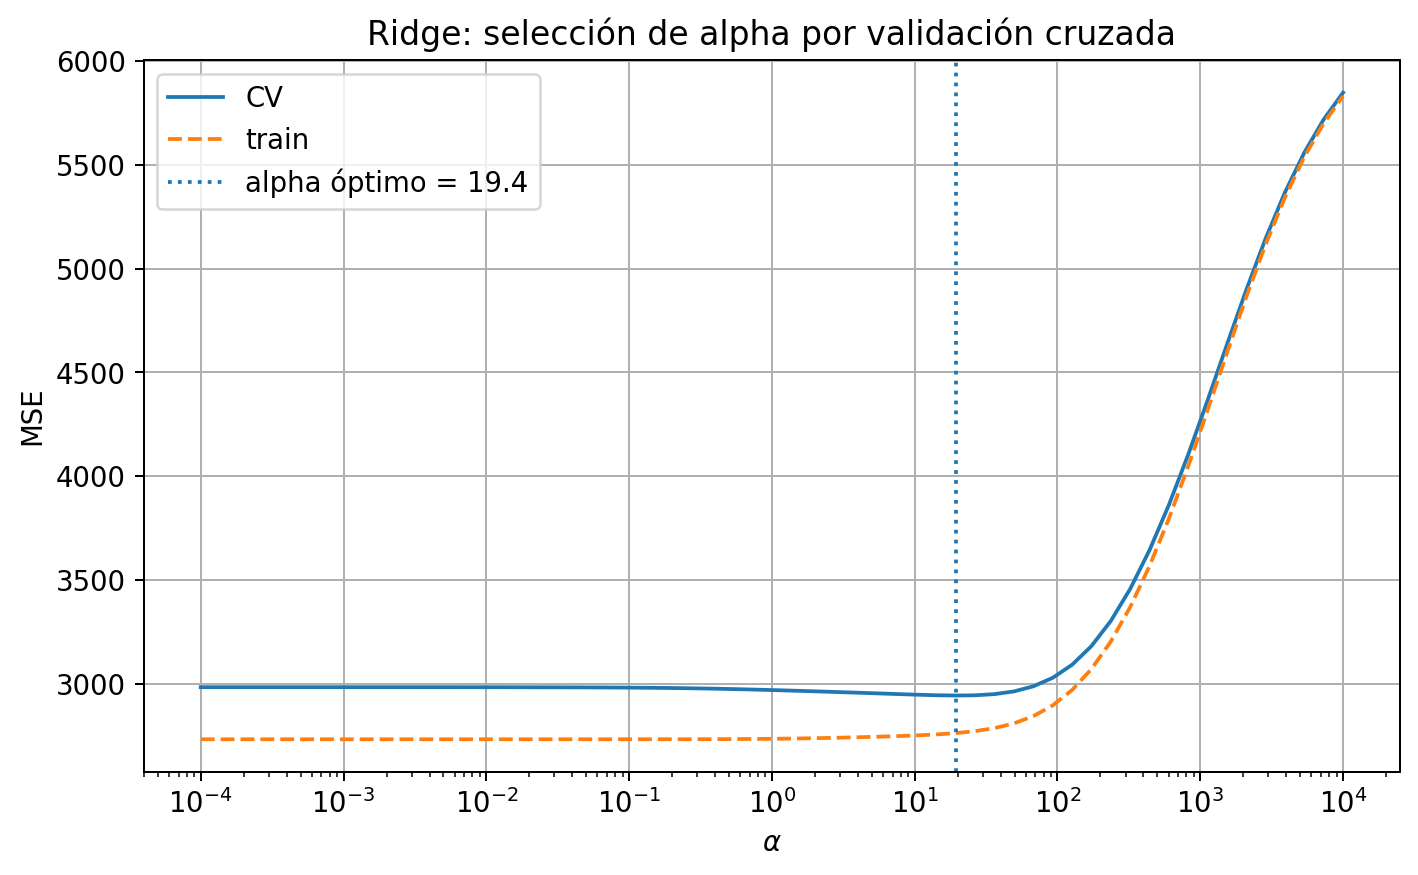

Figura guardada en: figs_lasso_ridge_elasticnet/06_ridge_cv_alpha.png


In [ ]:
ridge_cv = pd.DataFrame(ridge_grid.cv_results_)
ridge_cv["alpha"] = ridge_cv["param_model__alpha"].astype(float)
ridge_cv["mse_cv"] = -ridge_cv["mean_test_score"]
ridge_cv["mse_train"] = -ridge_cv["mean_train_score"]

plt.figure(figsize=(8, 5))
plt.semilogx(ridge_cv["alpha"], ridge_cv["mse_cv"], label="CV")
plt.semilogx(ridge_cv["alpha"], ridge_cv["mse_train"], linestyle="--", label="train")
plt.axvline(alpha_ridge, linestyle=":", label=f"alpha óptimo = {alpha_ridge:.3g}")
plt.xlabel(r"$\alpha$")
plt.ylabel("MSE")
plt.title("Ridge: selección de alpha por validación cruzada")
plt.legend()
guardar_figura("06_ridge_cv_alpha.png")

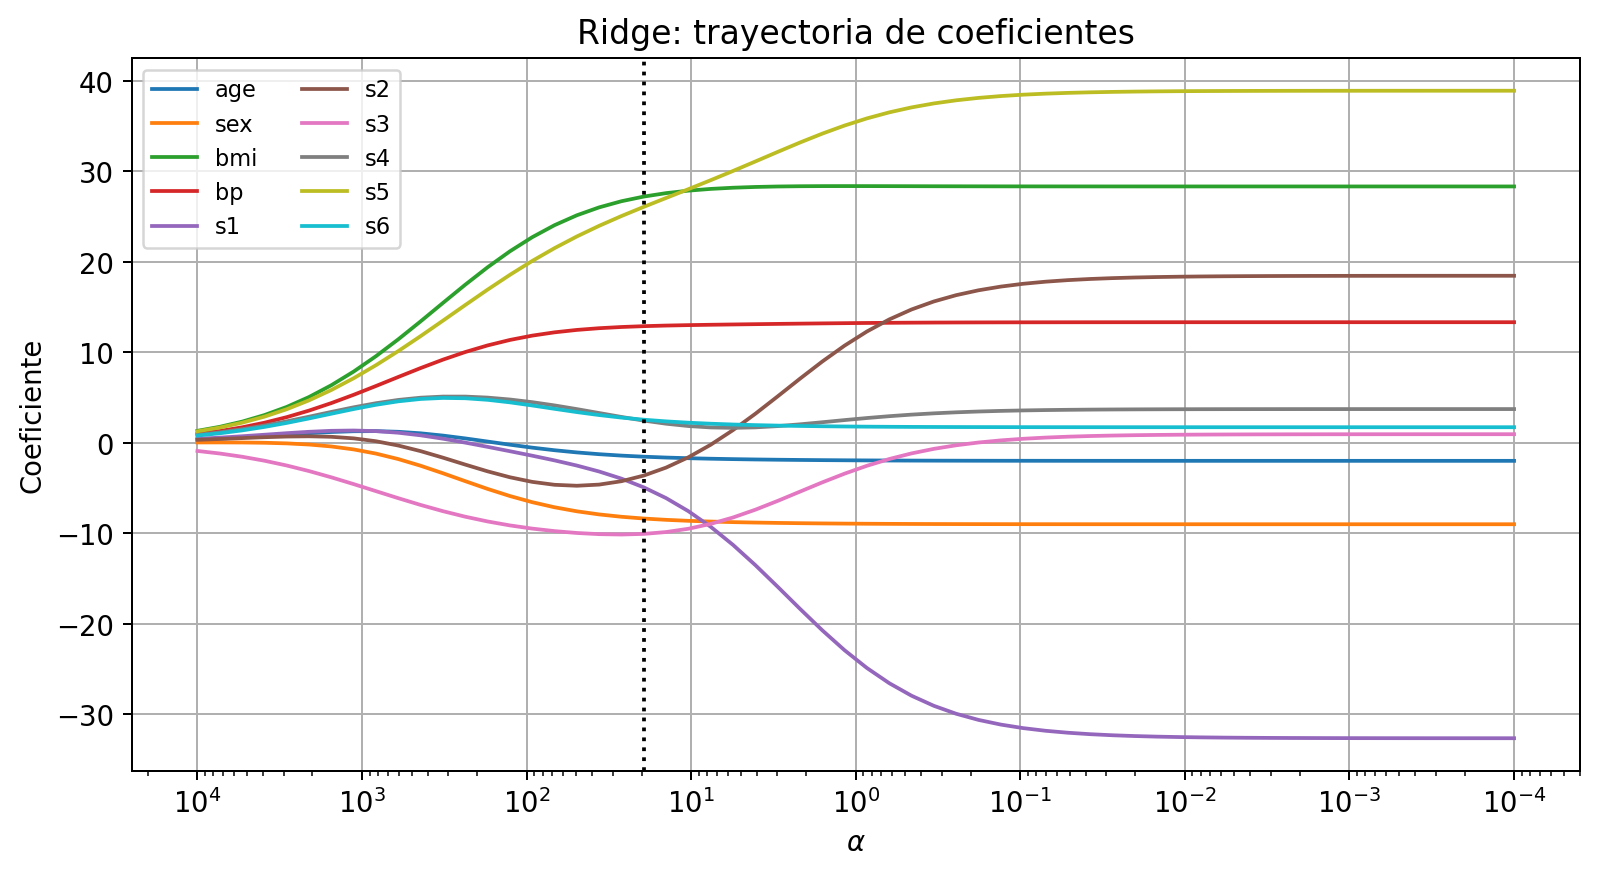

Figura guardada en: figs_lasso_ridge_elasticnet/07_ridge_coef_path.png


In [ ]:
# Trayectoria de coeficientes Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

coefs_ridge = []
for a in alphas_ridge:
    m = Ridge(alpha=a)
    m.fit(X_train_scaled, y_train)
    coefs_ridge.append(m.coef_)
coefs_ridge = np.array(coefs_ridge)

plt.figure(figsize=(9, 5))
for j, col in enumerate(X.columns):
    plt.semilogx(alphas_ridge, coefs_ridge[:, j], label=col)
plt.axvline(alpha_ridge, linestyle=":", color="black")
plt.gca().invert_xaxis()
plt.xlabel(r"$\alpha$")
plt.ylabel("Coeficiente")
plt.title("Ridge: trayectoria de coeficientes")
plt.legend(ncol=2, fontsize=9)
guardar_figura("07_ridge_coef_path.png")

# 8. LASSO

LASSO penaliza la suma de valores absolutos. A diferencia de Ridge, puede dejar coeficientes exactamente en cero. Por eso se usa como método de selección de variables.

In [ ]:
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=100000, random_state=RANDOM_STATE))
])

lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid={"model__alpha": alphas_sparse},
    scoring="neg_mean_squared_error",
    cv=kf,
    return_train_score=True,
    n_jobs=None
)
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
alpha_lasso = lasso_grid.best_params_["model__alpha"]

print("Mejor alpha para LASSO:", alpha_lasso)
print("MSE medio CV:", -lasso_grid.best_score_)

evaluar_modelo("LASSO", best_lasso, X_test, y_test)

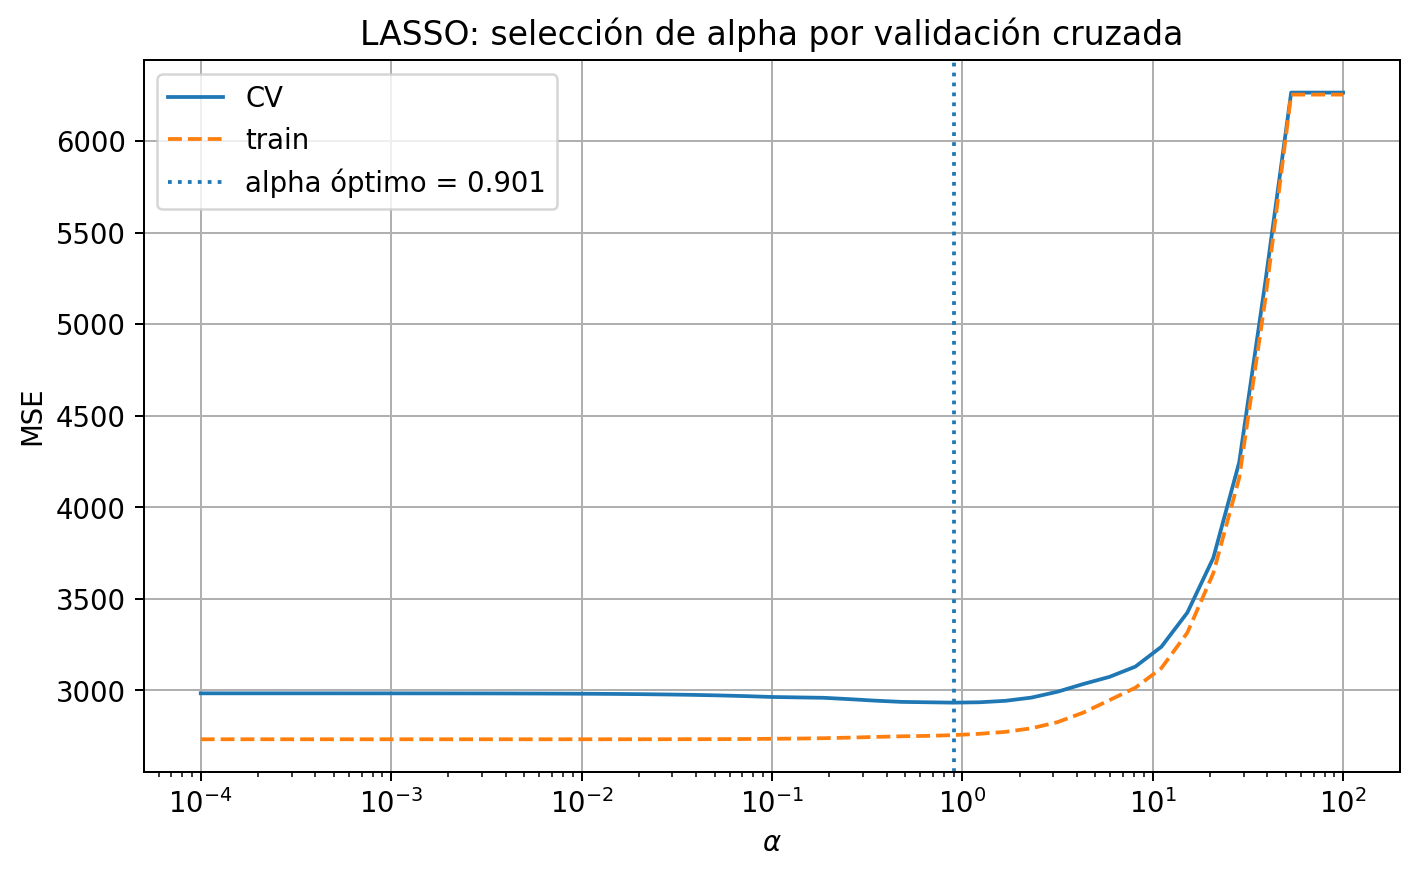

Figura guardada en: figs_lasso_ridge_elasticnet/08_lasso_cv_alpha.png


In [ ]:
lasso_cv = pd.DataFrame(lasso_grid.cv_results_)
lasso_cv["alpha"] = lasso_cv["param_model__alpha"].astype(float)
lasso_cv["mse_cv"] = -lasso_cv["mean_test_score"]
lasso_cv["mse_train"] = -lasso_cv["mean_train_score"]

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_cv["alpha"], lasso_cv["mse_cv"], label="CV")
plt.semilogx(lasso_cv["alpha"], lasso_cv["mse_train"], linestyle="--", label="train")
plt.axvline(alpha_lasso, linestyle=":", label=f"alpha óptimo = {alpha_lasso:.3g}")
plt.xlabel(r"$\alpha$")
plt.ylabel("MSE")
plt.title("LASSO: selección de alpha por validación cruzada")
plt.legend()
guardar_figura("08_lasso_cv_alpha.png")

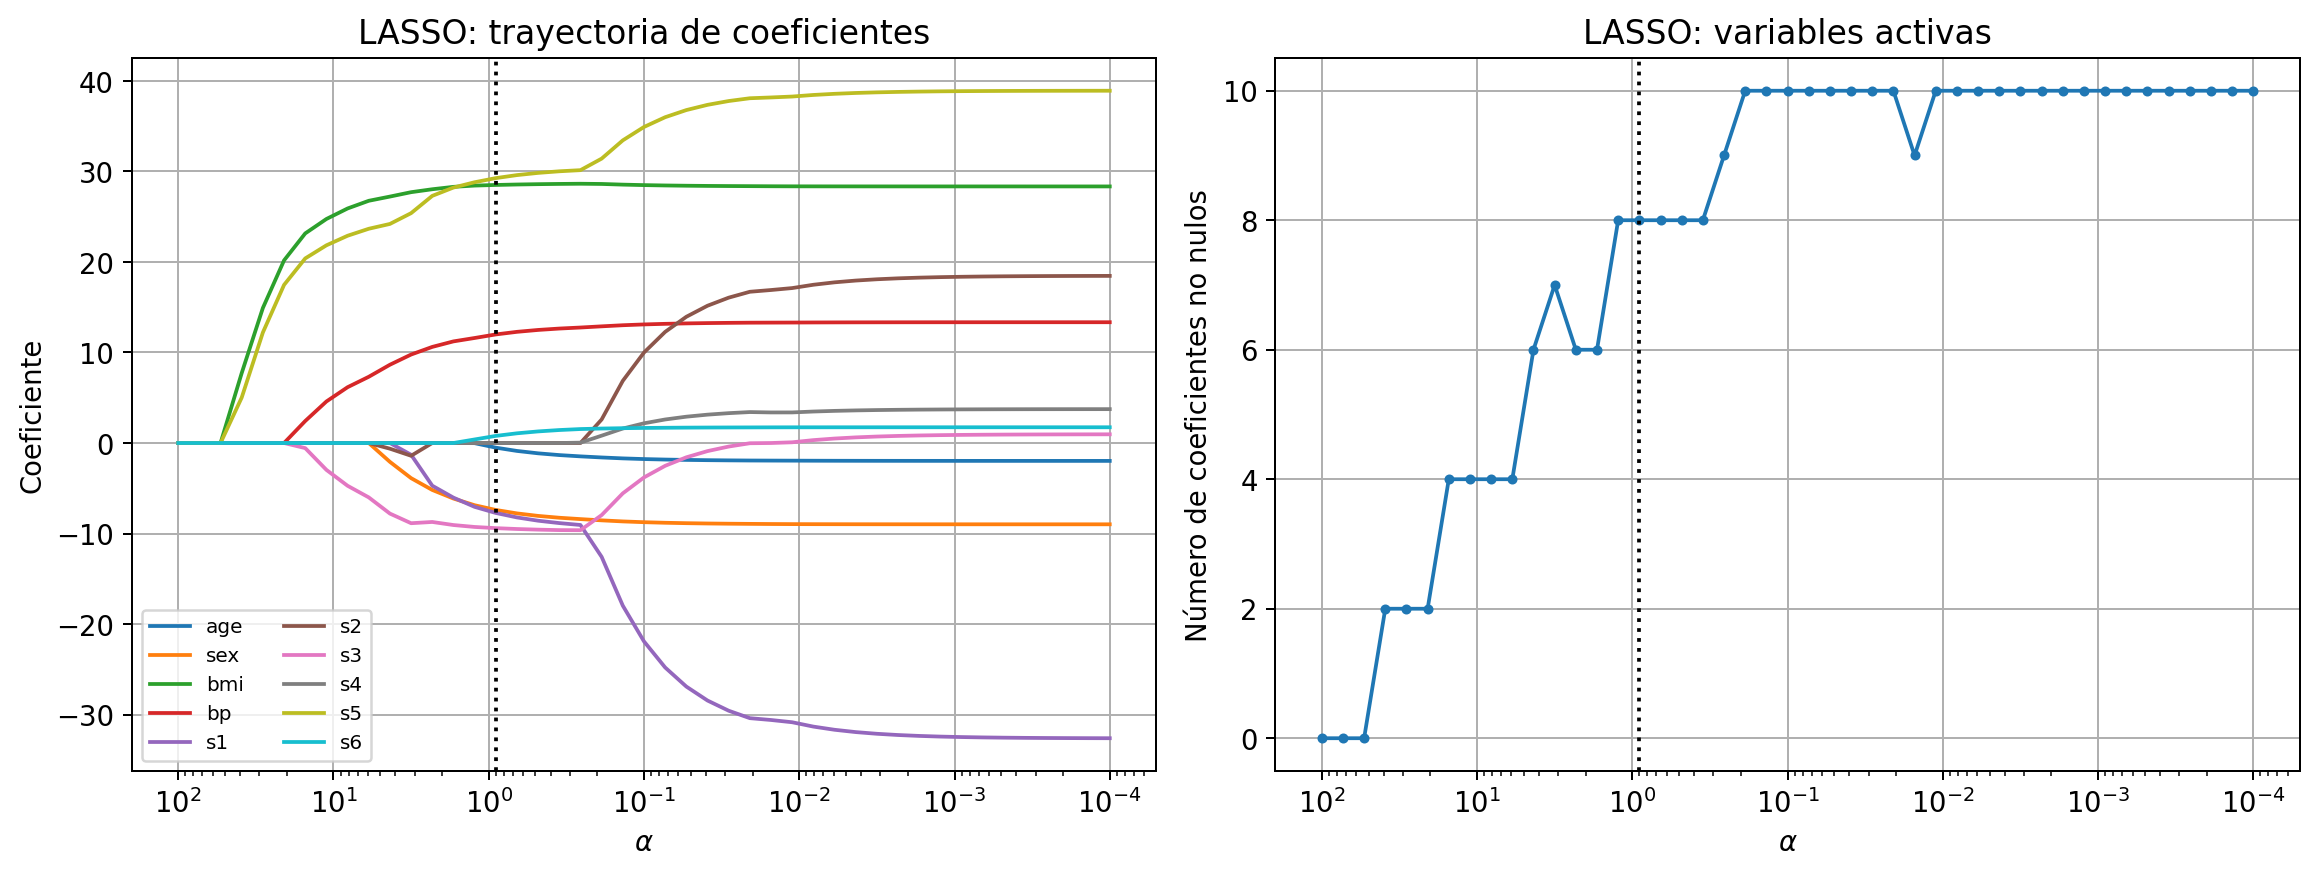

Figura guardada en: figs_lasso_ridge_elasticnet/09_lasso_coef_path_y_sparsity.png


In [ ]:
coefs_lasso = []
nonzero_lasso = []
for a in alphas_sparse:
    m = Lasso(alpha=a, max_iter=100000, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    coefs_lasso.append(m.coef_)
    nonzero_lasso.append(np.sum(np.abs(m.coef_) > 1e-8))
coefs_lasso = np.array(coefs_lasso)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for j, col in enumerate(X.columns):
    axes[0].semilogx(alphas_sparse, coefs_lasso[:, j], label=col)
axes[0].axvline(alpha_lasso, linestyle=":", color="black")
axes[0].invert_xaxis()
axes[0].set_xlabel(r"$\alpha$")
axes[0].set_ylabel("Coeficiente")
axes[0].set_title("LASSO: trayectoria de coeficientes")
axes[0].legend(ncol=2, fontsize=8)

axes[1].semilogx(alphas_sparse, nonzero_lasso, marker="o", markersize=3)
axes[1].axvline(alpha_lasso, linestyle=":", color="black")
axes[1].invert_xaxis()
axes[1].set_xlabel(r"$\alpha$")
axes[1].set_ylabel("Número de coeficientes no nulos")
axes[1].set_title("LASSO: variables activas")

guardar_figura("09_lasso_coef_path_y_sparsity.png")

# 9. Elastic Net

Elastic Net mezcla la penalización L1 y L2. Tiene dos parámetros:

- \(\alpha\): intensidad total de la penalización;
- `l1_ratio`: proporción de penalización L1.

Cuando hay predictores correlacionados, Elastic Net puede ser más estable que LASSO puro.

In [ ]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

elastic_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=100000, random_state=RANDOM_STATE))
])

elastic_grid = GridSearchCV(
    estimator=elastic_pipe,
    param_grid={
        "model__alpha": alphas_sparse,
        "model__l1_ratio": l1_ratios
    },
    scoring="neg_mean_squared_error",
    cv=kf,
    return_train_score=True,
    n_jobs=None
)
elastic_grid.fit(X_train, y_train)

best_elastic = elastic_grid.best_estimator_
alpha_elastic = elastic_grid.best_params_["model__alpha"]
l1_ratio_elastic = elastic_grid.best_params_["model__l1_ratio"]

print("Mejor alpha para Elastic Net:", alpha_elastic)
print("Mejor l1_ratio para Elastic Net:", l1_ratio_elastic)
print("MSE medio CV:", -elastic_grid.best_score_)

evaluar_modelo("Elastic Net", best_elastic, X_test, y_test)

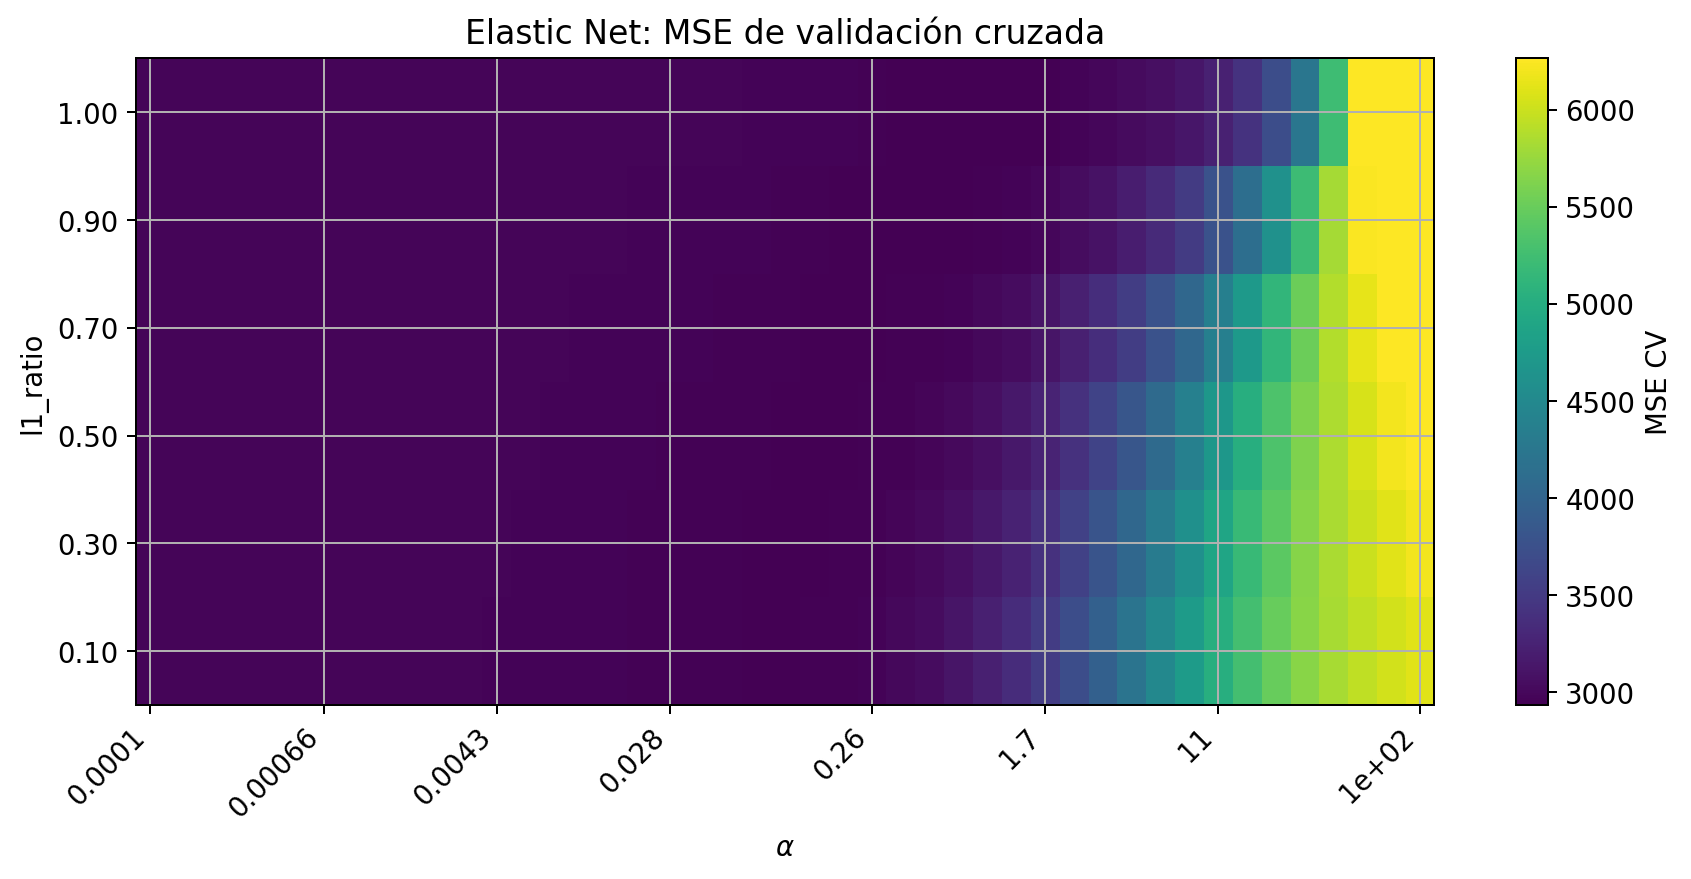

Figura guardada en: figs_lasso_ridge_elasticnet/10_elasticnet_heatmap_cv.png


In [ ]:
elastic_cv = pd.DataFrame(elastic_grid.cv_results_)
elastic_cv["alpha"] = elastic_cv["param_model__alpha"].astype(float)
elastic_cv["l1_ratio"] = elastic_cv["param_model__l1_ratio"].astype(float)
elastic_cv["mse_cv"] = -elastic_cv["mean_test_score"]

pivot = elastic_cv.pivot_table(index="l1_ratio", columns="alpha", values="mse_cv")

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, aspect="auto", origin="lower")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])

# Mostrar algunas marcas de alpha para no saturar el eje
alpha_values = pivot.columns.values.astype(float)
ticks = np.linspace(0, len(alpha_values)-1, 8, dtype=int)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{alpha_values[t]:.2g}" for t in ticks], rotation=45, ha="right")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("l1_ratio")
ax.set_title("Elastic Net: MSE de validación cruzada")
fig.colorbar(im, ax=ax, label="MSE CV")

guardar_figura("10_elasticnet_heatmap_cv.png")

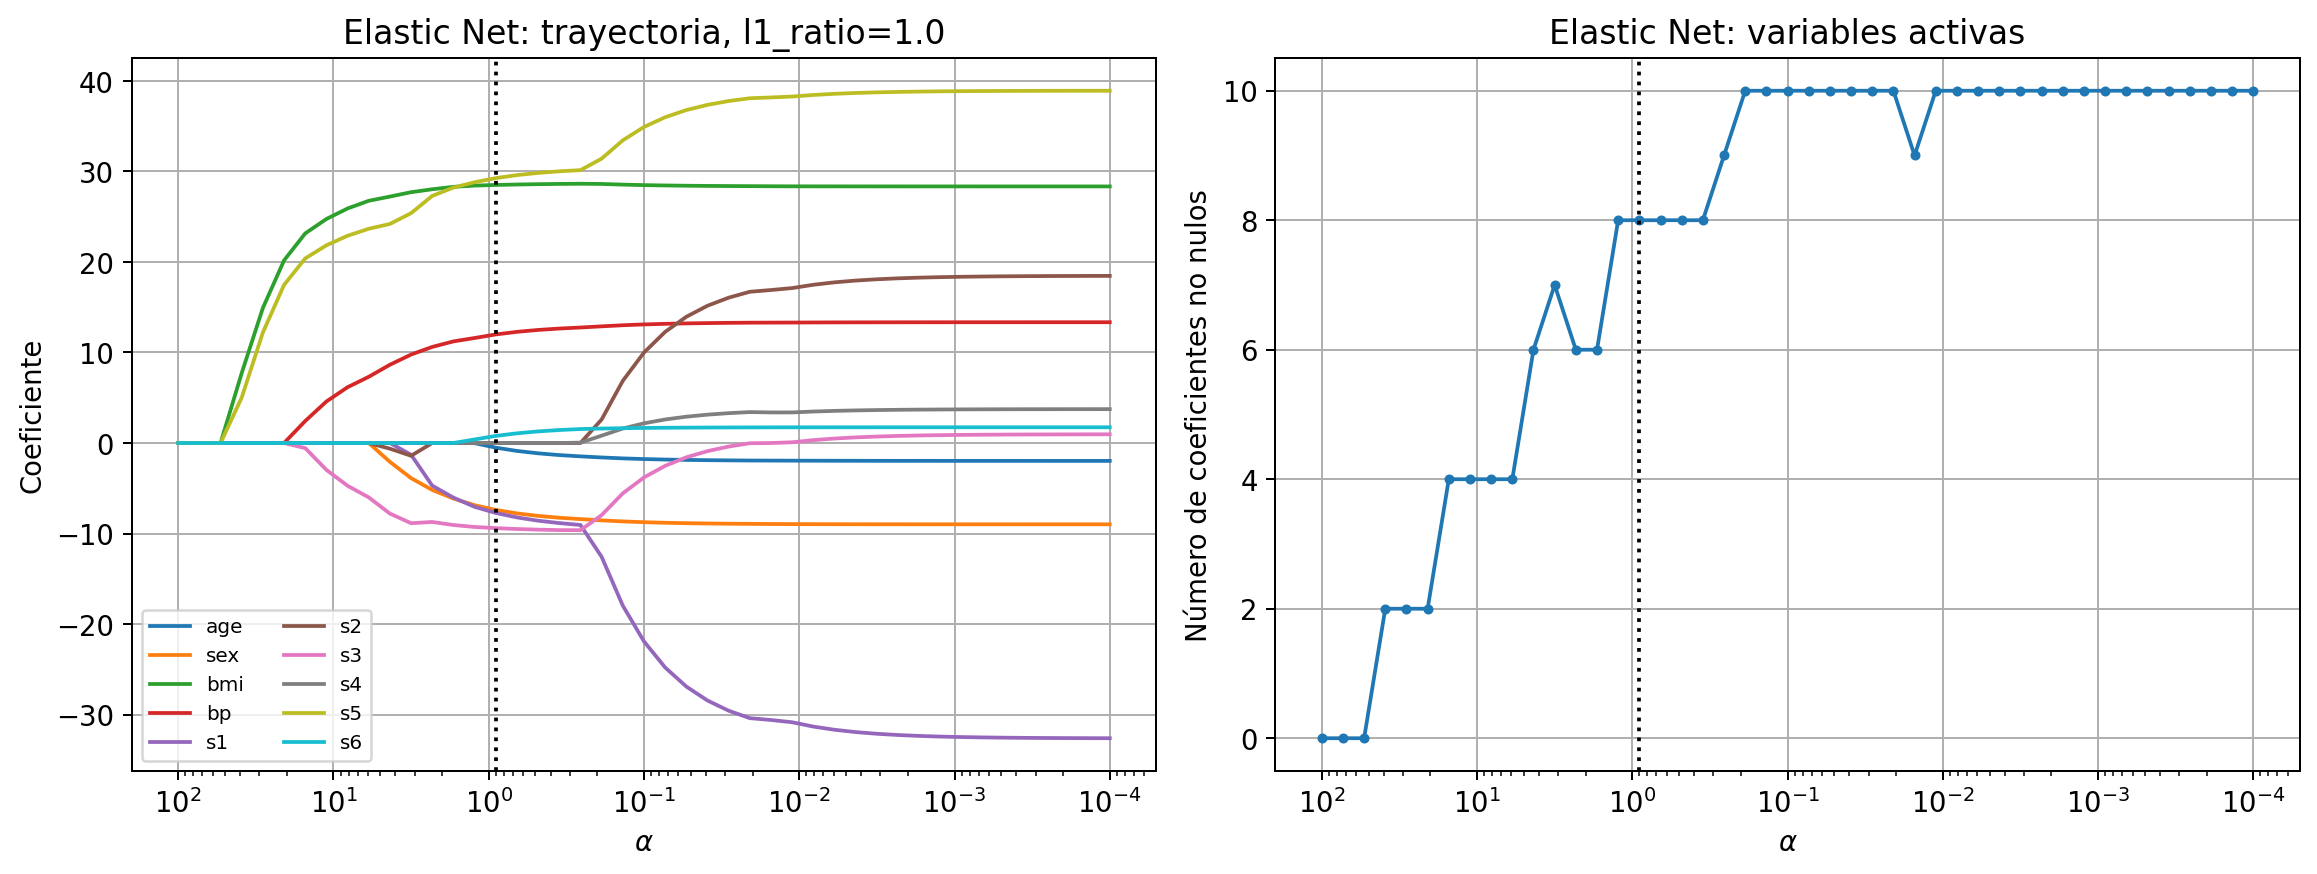

Figura guardada en: figs_lasso_ridge_elasticnet/11_elasticnet_coef_path_y_sparsity.png


In [ ]:
coefs_elastic = []
nonzero_elastic = []
for a in alphas_sparse:
    m = ElasticNet(alpha=a, l1_ratio=l1_ratio_elastic, max_iter=100000, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    coefs_elastic.append(m.coef_)
    nonzero_elastic.append(np.sum(np.abs(m.coef_) > 1e-8))
coefs_elastic = np.array(coefs_elastic)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for j, col in enumerate(X.columns):
    axes[0].semilogx(alphas_sparse, coefs_elastic[:, j], label=col)
axes[0].axvline(alpha_elastic, linestyle=":", color="black")
axes[0].invert_xaxis()
axes[0].set_xlabel(r"$\alpha$")
axes[0].set_ylabel("Coeficiente")
axes[0].set_title(f"Elastic Net: trayectoria, l1_ratio={l1_ratio_elastic}")
axes[0].legend(ncol=2, fontsize=8)

axes[1].semilogx(alphas_sparse, nonzero_elastic, marker="o", markersize=3)
axes[1].axvline(alpha_elastic, linestyle=":", color="black")
axes[1].invert_xaxis()
axes[1].set_xlabel(r"$\alpha$")
axes[1].set_ylabel("Número de coeficientes no nulos")
axes[1].set_title("Elastic Net: variables activas")

guardar_figura("11_elasticnet_coef_path_y_sparsity.png")

# 10. Comparación final de modelos

Ahora comparamos:

1. regresión lineal sin regularización;
2. Ridge;
3. LASSO;
4. Elastic Net.

La comparación se hace en el conjunto de prueba, que no fue usado para seleccionar los hiperparámetros.

In [ ]:
modelos = {
    "Regresión lineal": modelo_lineal,
    "Ridge": best_ridge,
    "LASSO": best_lasso,
    "Elastic Net": best_elastic,
}

metricas = pd.DataFrame([
    evaluar_modelo(nombre, modelo, X_test, y_test)
    for nombre, modelo in modelos.items()
]).sort_values("RMSE")

metricas

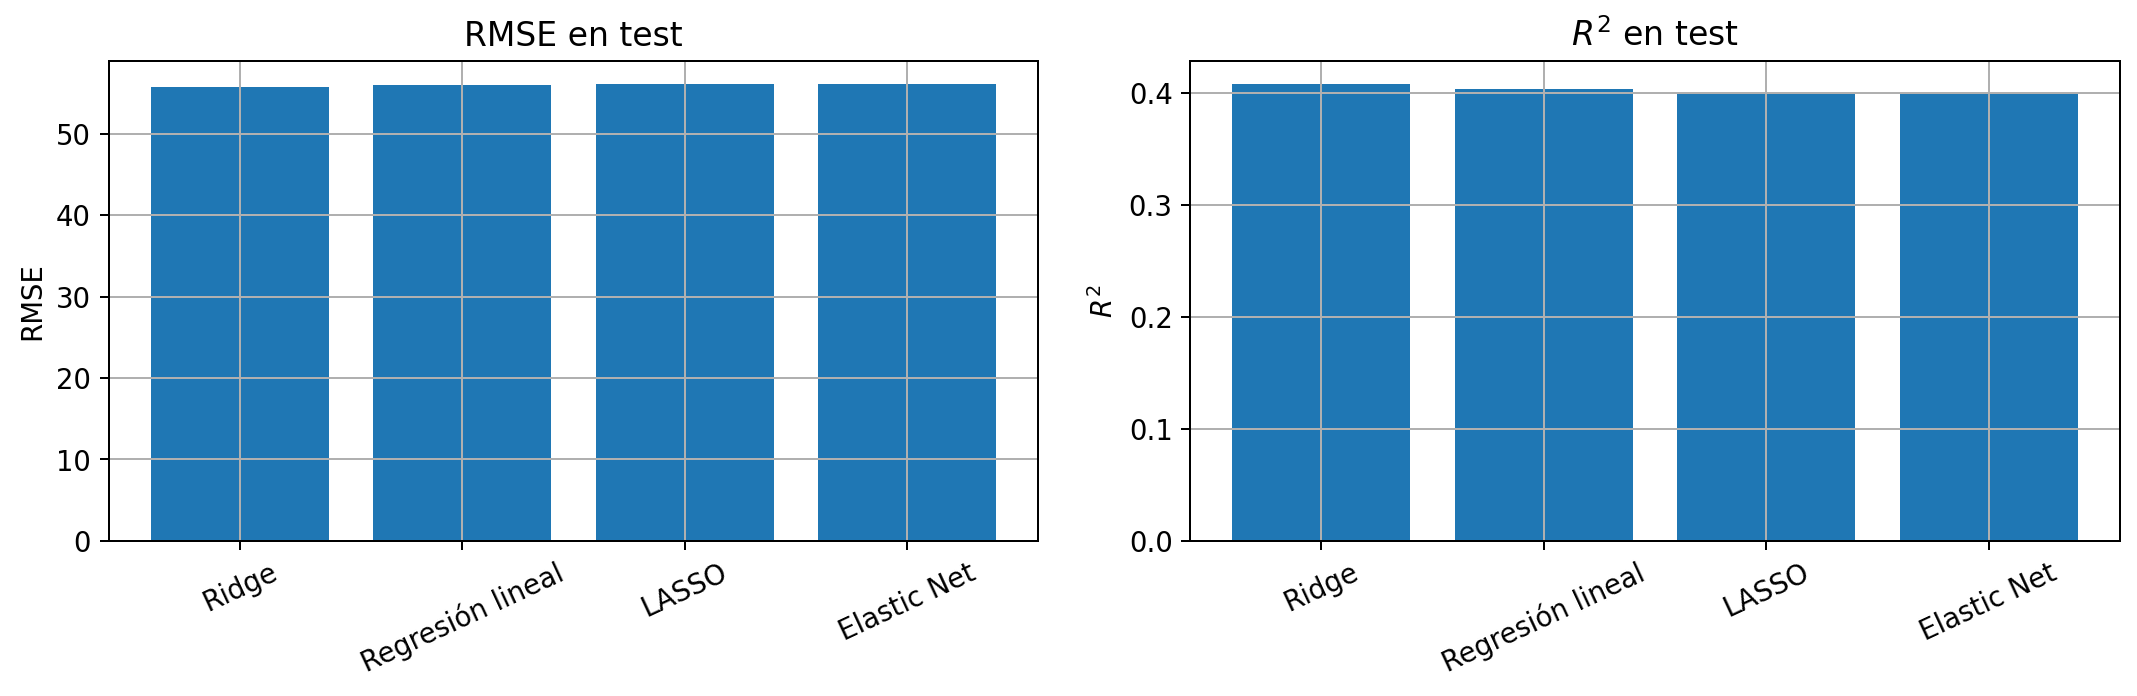

Figura guardada en: figs_lasso_ridge_elasticnet/12_comparacion_metricas.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(metricas["modelo"], metricas["RMSE"])
axes[0].set_title("RMSE en test")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(metricas["modelo"], metricas["R2"])
axes[1].set_title(r"$R^2$ en test")
axes[1].set_ylabel(r"$R^2$")
axes[1].tick_params(axis="x", rotation=25)

guardar_figura("12_comparacion_metricas.png")

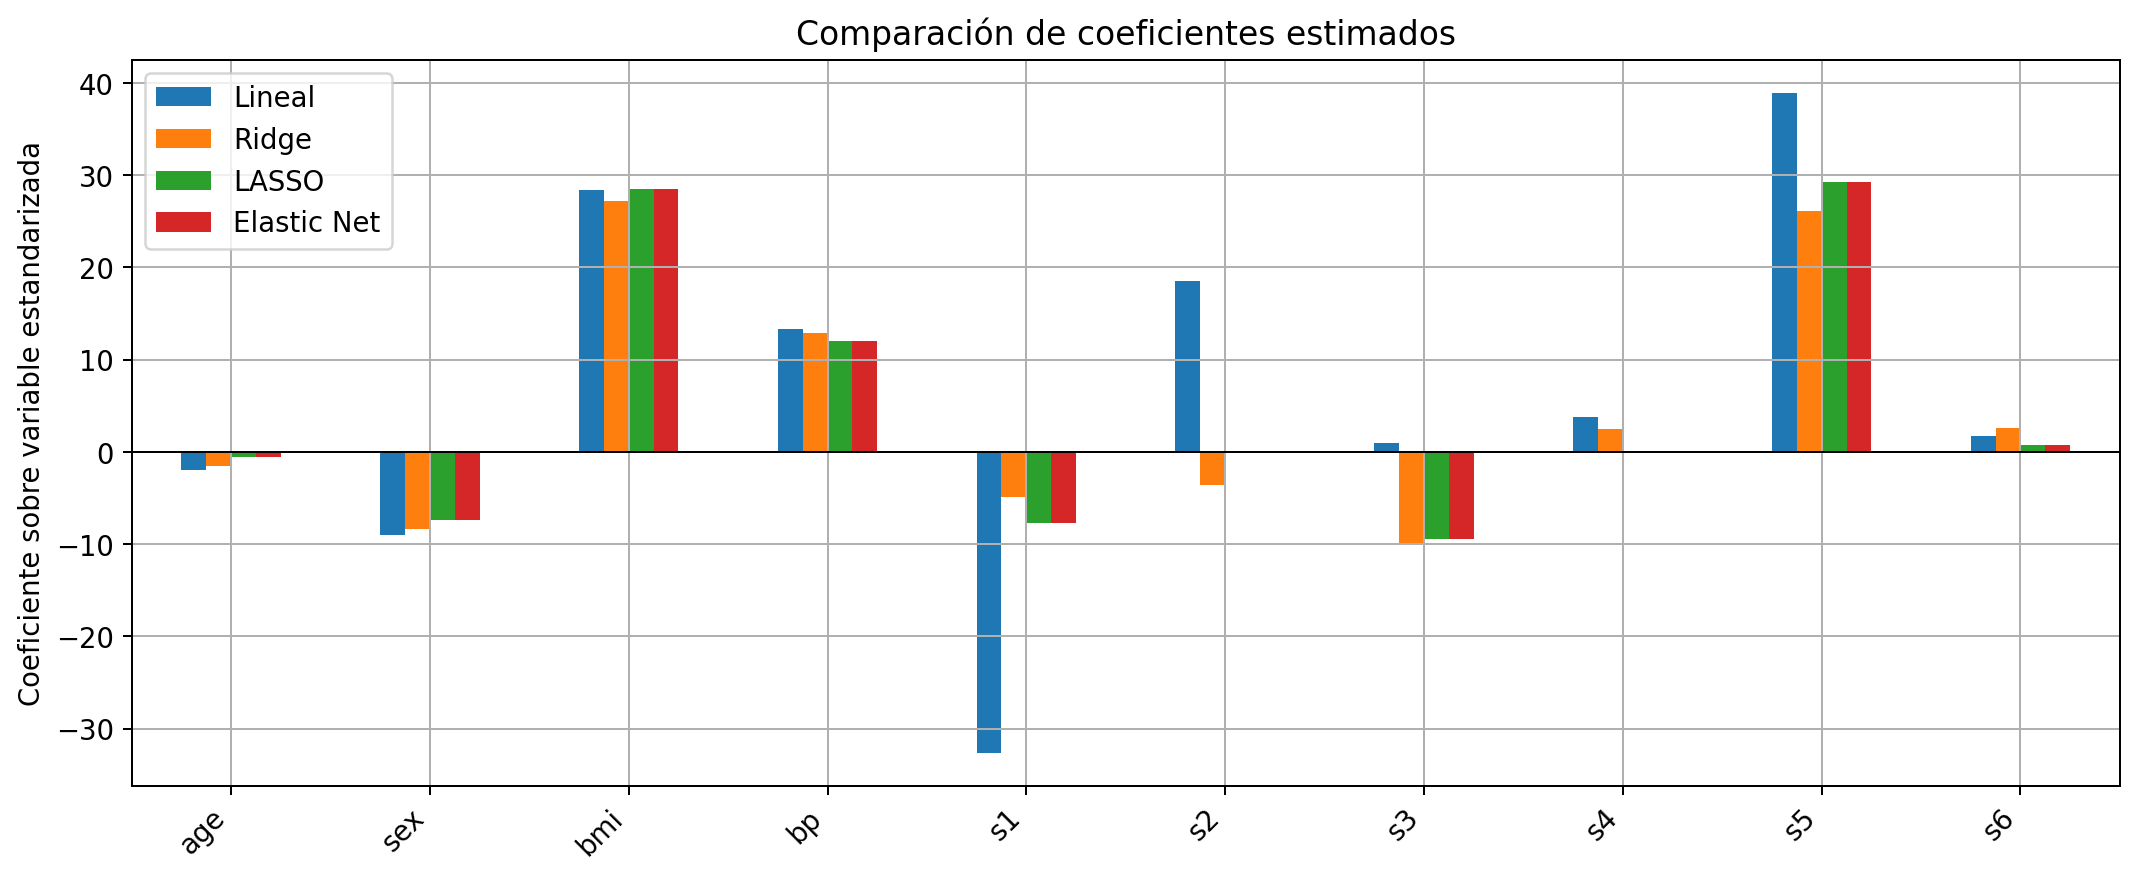

Figura guardada en: figs_lasso_ridge_elasticnet/13_comparacion_coeficientes.png


In [ ]:
coefs = pd.DataFrame(index=X.columns)
coefs["Lineal"] = modelo_lineal.named_steps["model"].coef_
coefs["Ridge"] = best_ridge.named_steps["model"].coef_
coefs["LASSO"] = best_lasso.named_steps["model"].coef_
coefs["Elastic Net"] = best_elastic.named_steps["model"].coef_

coefs.plot(kind="bar", figsize=(12, 5))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Comparación de coeficientes estimados")
plt.ylabel("Coeficiente sobre variable estandarizada")
plt.xticks(rotation=45, ha="right")
guardar_figura("13_comparacion_coeficientes.png")

coefs

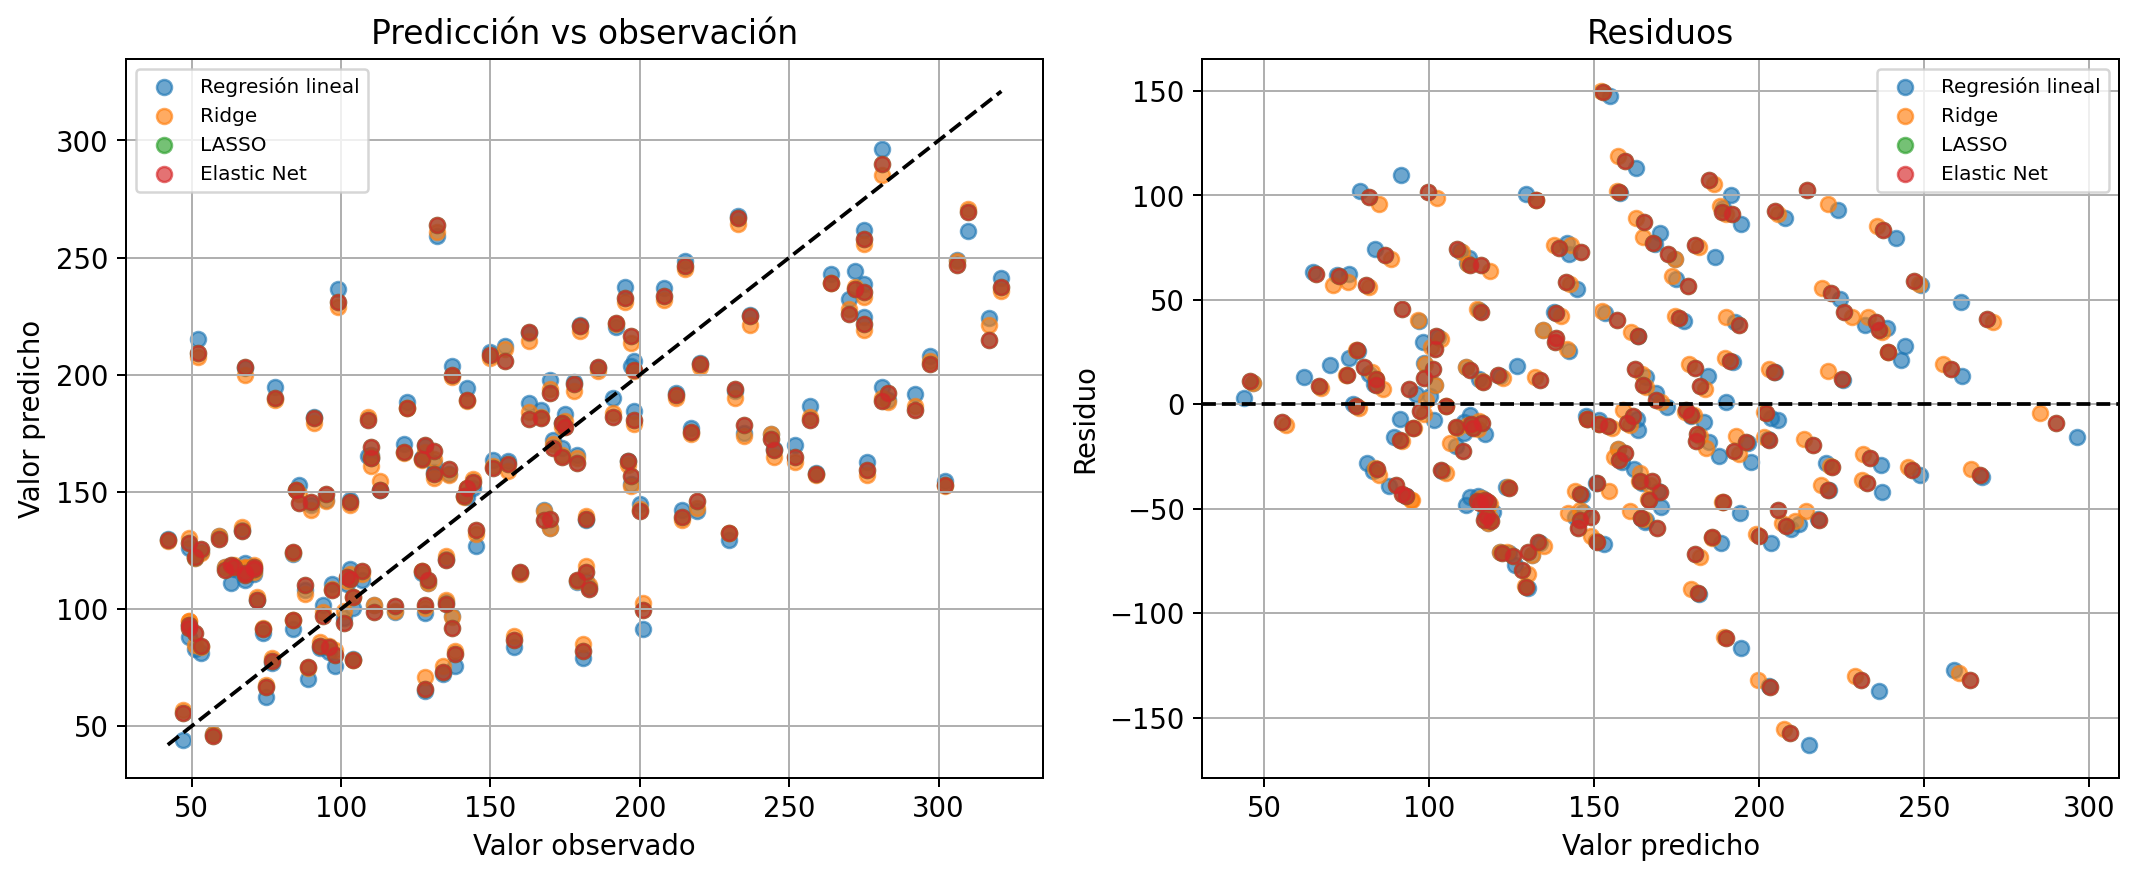

Figura guardada en: figs_lasso_ridge_elasticnet/14_predicho_vs_real_residuos.png


In [ ]:
# Predicho vs observado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for nombre, modelo in modelos.items():
    pred = modelo.predict(X_test)
    axes[0].scatter(y_test, pred, alpha=0.65, label=nombre)

min_val = min(y_test.min(), *(modelo.predict(X_test).min() for modelo in modelos.values()))
max_val = max(y_test.max(), *(modelo.predict(X_test).max() for modelo in modelos.values()))
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")
axes[0].set_xlabel("Valor observado")
axes[0].set_ylabel("Valor predicho")
axes[0].set_title("Predicción vs observación")
axes[0].legend(fontsize=8)

for nombre, modelo in modelos.items():
    pred = modelo.predict(X_test)
    resid = y_test - pred
    axes[1].scatter(pred, resid, alpha=0.65, label=nombre)
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_xlabel("Valor predicho")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos")
axes[1].legend(fontsize=8)

guardar_figura("14_predicho_vs_real_residuos.png")

# 11. Interpretación: reducción, selección y estabilidad

Una forma útil de resumir lo que ocurre es contar cuántos coeficientes quedan activos en cada modelo.

In [ ]:
resumen_coef = pd.DataFrame({
    "modelo": ["Lineal", "Ridge", "LASSO", "Elastic Net"],
    "coeficientes_no_nulos": [
        np.sum(np.abs(coefs["Lineal"]) > 1e-8),
        np.sum(np.abs(coefs["Ridge"]) > 1e-8),
        np.sum(np.abs(coefs["LASSO"]) > 1e-8),
        np.sum(np.abs(coefs["Elastic Net"]) > 1e-8),
    ],
    "norma_L1": [
        np.sum(np.abs(coefs["Lineal"])),
        np.sum(np.abs(coefs["Ridge"])),
        np.sum(np.abs(coefs["LASSO"])),
        np.sum(np.abs(coefs["Elastic Net"])),
    ],
    "norma_L2": [
        np.sqrt(np.sum(coefs["Lineal"]**2)),
        np.sqrt(np.sum(coefs["Ridge"]**2)),
        np.sqrt(np.sum(coefs["LASSO"]**2)),
        np.sqrt(np.sum(coefs["Elastic Net"]**2)),
    ]
})

resumen_coef

# 12. Función para el taller

A continuación queda una función que permite entrenar uno de los tres modelos regularizados. Esta función replica la idea del taller original, pero usando `Pipeline`, estandarización y validación cruzada.

In [ ]:
def entrenar_modelo_regularizado(
    X_train, y_train, X_test, y_test,
    penalizacion=1,
    alphas=None,
    l1_ratios=None,
    random_state=42
):
    """
    Entrena y evalúa un modelo regularizado.

    Parámetros
    ----------
    penalizacion : int
        1: LASSO
        2: Ridge
        3: Elastic Net

    Retorna
    -------
    dict con modelo, mejores hiperparámetros y métricas en test.
    """
    if alphas is None:
        alphas = np.logspace(-4, 3, 80)
    if l1_ratios is None:
        l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    if penalizacion == 1:
        nombre = "LASSO"
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(max_iter=100000, random_state=random_state))
        ])
        param_grid = {"model__alpha": alphas}

    elif penalizacion == 2:
        nombre = "Ridge"
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ])
        param_grid = {"model__alpha": alphas}

    elif penalizacion == 3:
        nombre = "Elastic Net"
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(max_iter=100000, random_state=random_state))
        ])
        param_grid = {"model__alpha": alphas, "model__l1_ratio": l1_ratios}

    else:
        raise ValueError("penalizacion debe ser 1=LASSO, 2=Ridge o 3=Elastic Net")

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=kf,
        return_train_score=True
    )
    grid.fit(X_train, y_train)

    pred = grid.predict(X_test)

    return {
        "nombre": nombre,
        "mejor_modelo": grid.best_estimator_,
        "mejores_parametros": grid.best_params_,
        "MSE_test": mean_squared_error(y_test, pred),
        "RMSE_test": mean_squared_error(y_test, pred)**0.5,
        "MAE_test": mean_absolute_error(y_test, pred),
        "R2_test": r2_score(y_test, pred),
        "grid": grid
    }

# Ejemplo de uso
resultado = entrenar_modelo_regularizado(X_train, y_train, X_test, y_test, penalizacion=3)
resultado["nombre"], resultado["mejores_parametros"], resultado["RMSE_test"], resultado["R2_test"]

# 13. Actividades sugeridas para la clase

1. Cambiar la partición train/test y observar si cambia el mejor modelo.
2. Cambiar el rango de valores de \(\alpha\). ¿Qué ocurre si el rango es demasiado pequeño?
3. Comparar los coeficientes de Ridge y LASSO. ¿Cuál reduce más? ¿Cuál elimina variables?
4. Usar únicamente las variables `bmi`, `bp` y `s5`. Comparar contra usar todas las variables.
5. Cambiar la lista de `l1_ratios` de Elastic Net. ¿Cuándo se parece más a Ridge? ¿Cuándo se parece más a LASSO?
6. Explicar por qué no debemos escoger \(\alpha\) usando directamente el conjunto test.

# 14. Conclusión didáctica

La regularización no es solamente una técnica para mejorar métricas. También permite controlar la complejidad del modelo.

- Ridge es útil cuando queremos estabilidad.
- LASSO es útil cuando queremos selección de variables.
- Elastic Net es útil cuando queremos una mezcla entre ambas ideas.

La idea central es que el modelo debe equilibrar dos fuerzas:

\[
\text{ajustar bien los datos} \quad \text{vs.} \quad \text{mantener coeficientes controlados}.
\]